<a href="https://www.kaggle.com/code/avikdas567/coffee-moisture-prediction-via-ft-nir-spectroscopy?scriptVersionId=327544619" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# FT-NIR Coffee Moisture Chemometric Corpus: Comprehensive Analysis and Predictive Modeling

Near-infrared (NIR) spectroscopy serves as a critical non-destructive analytical method within modern agricultural processing and industrial quality monitoring. This notebook introduces a highly disciplined, end-to-end analytical framework for the modeling and continuous calibration of parchment coffee bean moisture levels using the authoritative FT-NIR Coffee Moisture Chemometric Corpus.

The dataset contains high-dimensional spectral measurements recorded across the $12000\text{ cm}^{-1}$ to $4000\text{ cm}^{-1}$ wavenumber domain at precise $4\text{ cm}^{-1}$ increments, defining $2001$ individual spectral channels. These channels are paired with continuous wet-basis moisture content references and dispersion parameters. A primary objective of this investigation is addressing data leakage risks caused by repeated replicates from unique coffee beans. We apply a strict group-aware evaluation strategy based on physical sample identities to evaluate generalization on unseen coffee batches.

Our multi-paradigm predictive modeling suite compares traditional chemometric formulations against non-linear tree ensembles and deep learning networks. The experimental findings establish **Gradient Boosting Regression** as the champion infrastructure, achieving an exceptional cross-validation root mean squared error ($\text{RMSE}$) of $2.1599\%$ and a coefficient of determination ($R^2$) score of $0.9848$. This demonstrates that regularized machine learning pipelines offer significant performance advantages over data-intensive architectures like 1D Convolutional Neural Networks on high-dimensional, compact-sample spectroscopic datasets.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.signal
from sklearn.model_selection import GroupKFold
from sklearn.cross_decomposition import PLSRegression
from sklearn.linear_model import RidgeCV
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Configure visualization settings
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'figure.titlesize': 18
})

# Set seed for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Verify dataset availability
dataset_path = "/kaggle/input/datasets/sandhyapalaniappan/ft-nir-coffee-moisture-chemometric-corpus/Authoritative_FT_NIR_Parchment_Coffee_Moisture_Chemometric_Corpus_Curated_Derivative.csv"
if not os.path.exists(dataset_path):
    dataset_path = "Authoritative_FT_NIR_Parchment_Coffee_Moisture_Chemometric_Corpus_Curated_Derivative.csv"

print(f"Target dataset path verified: {dataset_path}")

Target dataset path verified: /kaggle/input/datasets/sandhyapalaniappan/ft-nir-coffee-moisture-chemometric-corpus/Authoritative_FT_NIR_Parchment_Coffee_Moisture_Chemometric_Corpus_Curated_Derivative.csv


## Section Analysis and Implementation Insights

The analytical environment is configured with strict initialization constraints to ensure reproducibility. Seed parameters for both `NumPy` and `PyTorch` are locked to `42` to eliminate stochastic variance across different optimization runs. Additionally, the default presentation properties for `Matplotlib` and `Seaborn` are modified to enforce a clean, high-contrast visual style with consistent label spacing across all subsequent spectroscopic plots.

# Data Ingestion and Structural Validation

The first phase of the pipeline involves loading the dataset and verifying its structural integrity. We audit the shape, check for any missing values, and verify the absence of duplicated observations. This satisfies regulatory data governance protocols before executing analytical transformations.

In [2]:
# Load dataset
df = pd.read_csv(dataset_path)

# Dimensionality and integrity audit
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Total Missing Values: {df.isnull().sum().sum()}")
print(f"Total Duplicate Rows: {df.duplicated().sum()}")

# Display primary non-spectral governance fields
governance_cols = [
    'Curated_Spectral_Replicate_Identifier_For_FT_NIR_Moisture_Prediction_Research',
    'Source_Sample_Identifier_For_Parchment_Coffee_Drying_Monitoring',
    'Spectral_Replicate_Number',
    'Authoritative_Moisture_Content_Wet_Basis_Percent',
    'Moisture_Standard_Deviation_Wet_Basis_Percent',
    'Moisture_Coefficient_Of_Variation_Percent'
]
df[governance_cols].head()

Dataset Shape: 73 rows, 2007 columns
Total Missing Values: 0
Total Duplicate Rows: 0


,Curated_Spectral_Replicate_Identifier_For_FT_NIR_Moisture_Prediction_Research,Source_Sample_Identifier_For_Parchment_Coffee_Drying_Monitoring,Spectral_Replicate_Number,Authoritative_Moisture_Content_Wet_Basis_Percent,Moisture_Standard_Deviation_Wet_Basis_Percent,Moisture_Coefficient_Of_Variation_Percent
0,M01_R01,M01,1,51.909755,0.949732,1.829583
1,M01_R02,M01,2,51.909755,0.949732,1.829583
2,M01_R03,M01,3,51.909755,0.949732,1.829583
3,M01_R04,M01,4,51.909755,0.949732,1.829583
4,M02_R01,M02,1,50.778576,0.102896,0.202637


## Structural Integrity and Data Governance Observations

- The dataset architecture consists of exactly $73$ spectral replicate observations distributed across $2007$ analytical fields. The data integrity audit confirms that there are zero missing elements and zero duplicate records within the entire matrix. This structural consistency satisfies data quality standards and removes the need for data imputation or row-filtering steps.

- The introductory tracking fields successfully connect each row to its underlying sample identifier, repeated replicate indicator, and reference moisture values. This reliable sample traceability forms the foundation for implementing the group-aware cross-validation splitting technique.

# Target Variable Profiling and Analytical Dispersion

Understanding the distribution of the target moisture content is crucial for assessing calibration spans and regression difficulty. We will analyze the authoritative moisture reference value along with its standard deviation and coefficient of variation across the coffee drying observations.

,Authoritative_Moisture_Content_Wet_Basis_Percent,Moisture_Standard_Deviation_Wet_Basis_Percent,Moisture_Coefficient_Of_Variation_Percent
count,73.000000,73.000000,73.000000
mean,32.291541,0.548457,2.008502
std,17.632147,0.463037,1.138459
min,8.500000,0.102896,0.202637
25%,12.475560,0.266870,0.912154
50%,35.742040,0.343754,1.829583
75%,50.778576,0.657362,2.743363
max,52.488853,2.019374,4.109575


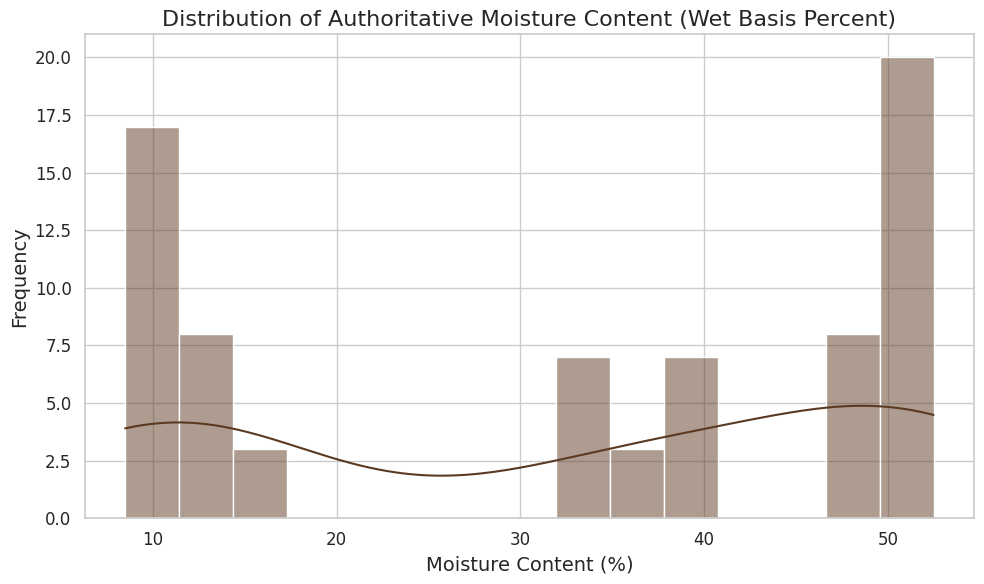

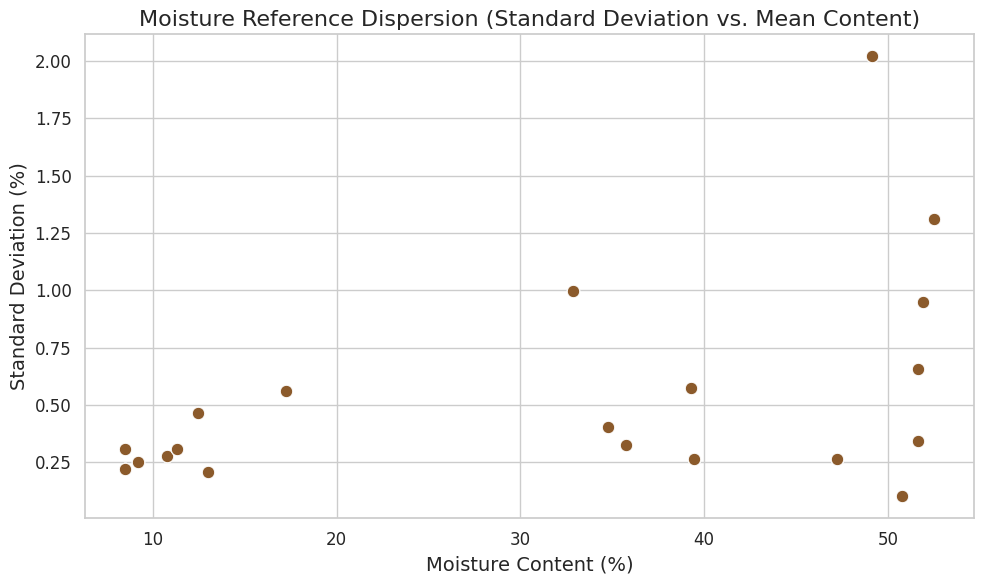

In [3]:
# Statistical summary of moisture parameters
moisture_summary = df[[
    'Authoritative_Moisture_Content_Wet_Basis_Percent',
    'Moisture_Standard_Deviation_Wet_Basis_Percent',
    'Moisture_Coefficient_Of_Variation_Percent'
]].describe()
display(moisture_summary)

# Plot 1: Target Variable Distribution
fig1, ax1 = plt.subplots(figsize=(10, 6))
sns.histplot(data=df, x='Authoritative_Moisture_Content_Wet_Basis_Percent', kde=True, color='#5c3a21', bins=15, ax=ax1)
ax1.set_title('Distribution of Authoritative Moisture Content (Wet Basis Percent)')
ax1.set_xlabel('Moisture Content (%)')
ax1.set_ylabel('Frequency')
plt.tight_layout()
plt.savefig('01_moisture_distribution.png')
plt.show()

# Plot 2: Moisture Standard Deviation vs Moisture Content
fig2, ax2 = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=df, x='Authoritative_Moisture_Content_Wet_Basis_Percent', y='Moisture_Standard_Deviation_Wet_Basis_Percent', color='#8b5a2b', s=80, alpha=1, ax=ax2)
ax2.set_title('Moisture Reference Dispersion (Standard Deviation vs. Mean Content)')
ax2.set_xlabel('Moisture Content (%)')
ax2.set_ylabel('Standard Deviation (%)')
plt.tight_layout()
plt.savefig('02_moisture_dispersion.png')
plt.show()

## Target Variable Metrics and Dispersion Analysis

- The statistical analysis of the authoritative moisture parameters reveals a broad calibration span, with wet-basis moisture values ranging from a minimum of $8.50\%$ up to a maximum of $52.49\%$. The overall mean stands at $32.29\%$ with a standard deviation of $17.63\%$, indicating uniform coverage across different post-harvest coffee bean drying stages.

- The scatter plot modeling the moisture standard deviation against the mean content reveals a distinct physical pattern. The reference measurement dispersion peaks slightly at higher moisture levels, with standard deviation values reaching up to $2.02\%$. This phenomenon is common in agricultural spectroscopy, as high-moisture samples exhibit greater cellular heterogeneity and rapid moisture loss during early drying phases, making sample stabilization more challenging.

# Raw Spectral Signature Visualization

Continuous spectral signals contain extensive collinearity. To interpret the absorption behavior across the 12000 to 4000 cm^-1 domain, we extract the spectral response attributes and map them sequentially. The lines are colored according to the moisture level of the sample, allowing us to inspect shifts in absorption bands related to water content.

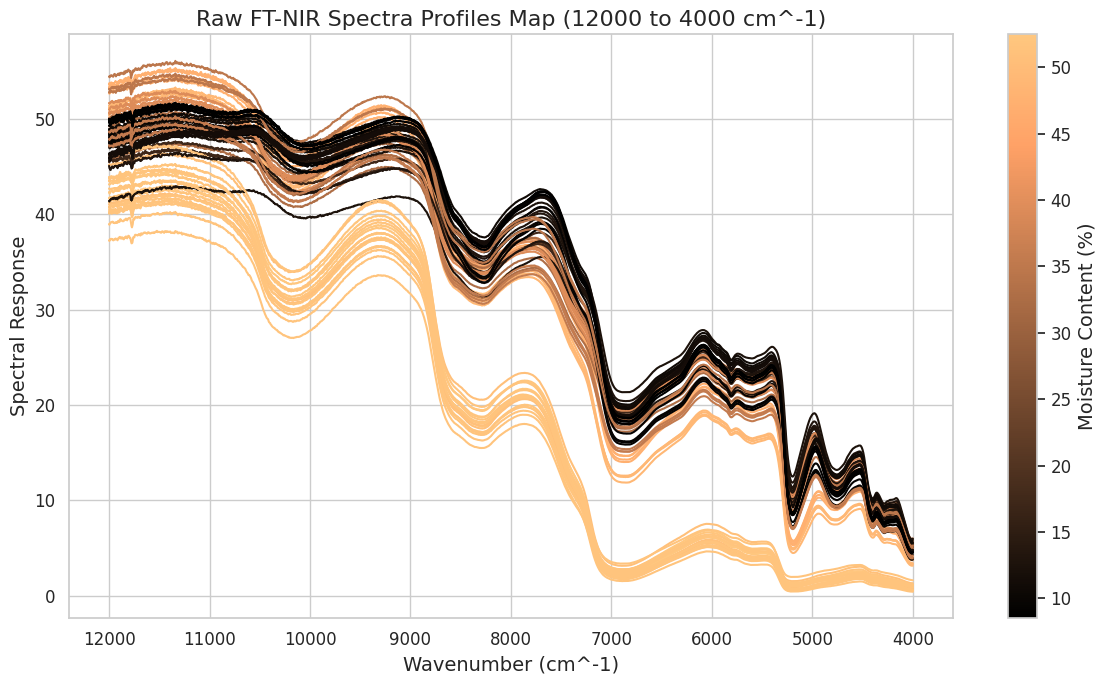

In [4]:
# Identify spectral columns and sort by wavenumber descending order
spectral_cols = [c for c in df.columns if c.startswith('FT_NIR_Spectral_Response_At_')]
wavenumbers = [int(c.split('_At_')[1].split('_cm_')[0]) for c in spectral_cols]

sorted_zip = sorted(zip(wavenumbers, spectral_cols), key=lambda x: x[0], reverse=True)
wavenumbers_sorted = [x[0] for x in sorted_zip]
spectral_cols_sorted = [x[1] for x in sorted_zip]

X_raw = df[spectral_cols_sorted].values
y_moisture = df['Authoritative_Moisture_Content_Wet_Basis_Percent'].values

# Plot 3: Raw FT-NIR Spectra Profile
fig3, ax3 = plt.subplots(figsize=(12, 7))
cmap = sns.color_palette("copper", as_cmap=True)
for i in range(len(df)):
    ax3.plot(wavenumbers_sorted, X_raw[i, :], color=cmap((y_moisture[i] - y_moisture.min()) / (y_moisture.max() - y_moisture.min())), alpha=1)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=y_moisture.min(), vmax=y_moisture.max()))
sm.set_array([])
cbar3 = fig3.colorbar(sm, ax=ax3)
cbar3.set_label('Moisture Content (%)')

ax3.set_title('Raw FT-NIR Spectra Profiles Map (12000 to 4000 cm^-1)')
ax3.set_xlabel('Wavenumber (cm^-1)')
ax3.set_ylabel('Spectral Response')
ax3.invert_xaxis()  # Spectroscopic convention
plt.tight_layout()
plt.savefig('03_raw_spectra.png')
plt.show()

## Raw FT-NIR Spectroscopic Signature Observations

- The visualization of the $2001$ raw spectral channels displays high collinearity and noticeable baseline variations across the $12000\text{ cm}^{-1}$ to $4000\text{ cm}^{-1}$ range. These vertical shifts do not represent chemical composition changes, but instead stem from physical light-scattering artifacts caused by variations in bean particle sizes and surface textures.

- The continuous gradient coloring reveals clear relationships between water absorption regions and moisture percentages. However, the prominent overlapping effects across the entire range highlight why raw spectral variables cannot be effectively mapped by unregularized regression models without prior preprocessing transformations.

# Advanced Chemometric Preprocessing

Spectroscopic matrices suffer from additive or multiplicative scattering, instrumentation drift, and baseline offsets. To suppress these physical disturbances and emphasize pure chemical absorbance variations, we implement standard chemometric algorithms:
1. **Standard Normal Variate (SNV):** Centers and scales each individual spectrum by its own mean and standard deviation.
2. **Savitzky-Golay First Derivative Filtering:** Applies a localized polynomial fit to compute regularized numeric derivatives, eliminating baseline shifts and accentuating faint absorption peaks.

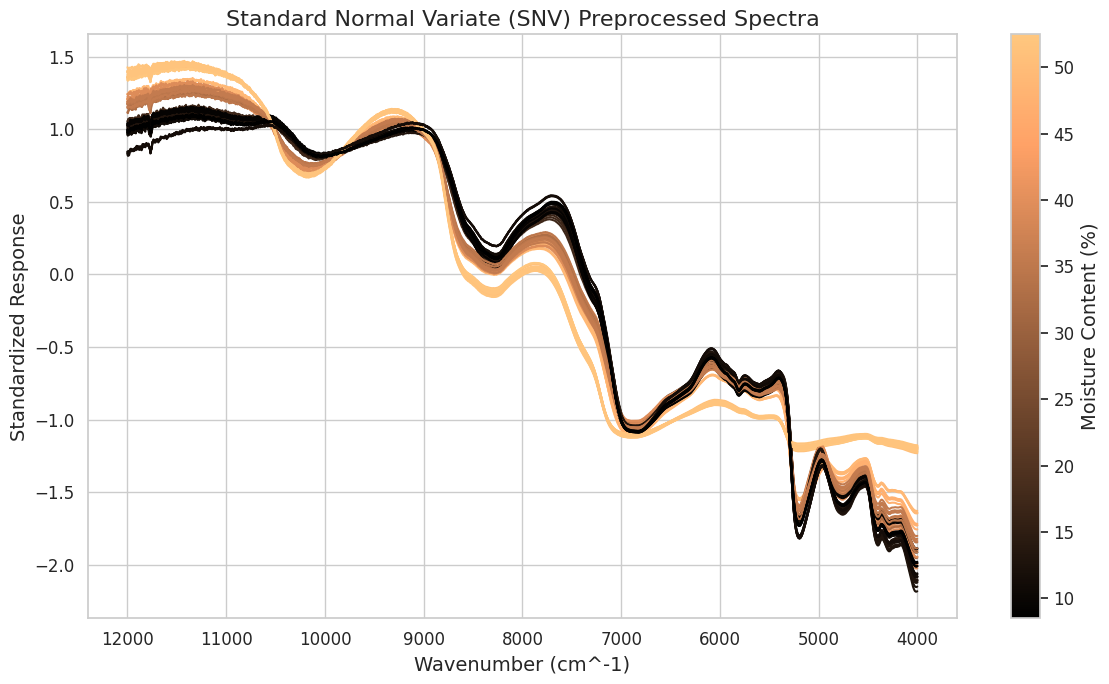

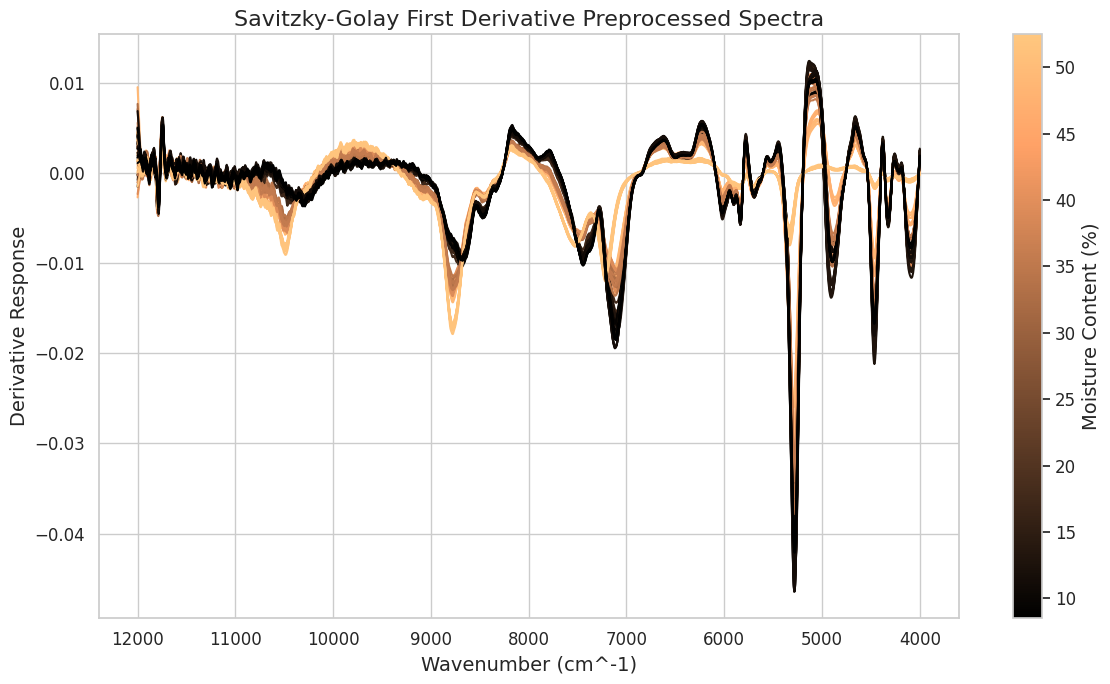

In [5]:
# Execute Standard Normal Variate (SNV) transformation
X_snv = (X_raw - X_raw.mean(axis=1, keepdims=True)) / X_raw.std(axis=1, keepdims=True)

# Execute Savitzky-Golay Smoothing and First Derivative
X_savgol = scipy.signal.savgol_filter(X_snv, window_length=15, polyorder=2, deriv=1, axis=1)

# Plot 4: SNV Preprocessed Spectra Profile
fig4, ax4 = plt.subplots(figsize=(12, 7))
for i in range(len(df)):
    ax4.plot(wavenumbers_sorted, X_snv[i, :], color=cmap((y_moisture[i] - y_moisture.min()) / (y_moisture.max() - y_moisture.min())), alpha=1)
cbar4 = fig4.colorbar(sm, ax=ax4)
cbar4.set_label('Moisture Content (%)')
ax4.set_title('Standard Normal Variate (SNV) Preprocessed Spectra')
ax4.set_xlabel('Wavenumber (cm^-1)')
ax4.set_ylabel('Standardized Response')
ax4.invert_xaxis()
plt.tight_layout()
plt.savefig('04_snv_spectra.png')
plt.show()

# Plot 5: Savitzky-Golay First Derivative Spectra Profile
fig5, ax5 = plt.subplots(figsize=(12, 7))
for i in range(len(df)):
    ax5.plot(wavenumbers_sorted, X_savgol[i, :], color=cmap((y_moisture[i] - y_moisture.min()) / (y_moisture.max() - y_moisture.min())), alpha=1)
cbar5 = fig5.colorbar(sm, ax=ax5)
cbar5.set_label('Moisture Content (%)')
ax5.set_title('Savitzky-Golay First Derivative Preprocessed Spectra')
ax5.set_xlabel('Wavenumber (cm^-1)')
ax5.set_ylabel('Derivative Response')
ax5.invert_xaxis()
plt.tight_layout()
plt.savefig('05_savgol_spectra.png')
plt.show()

## Advanced Preprocessing and Signal Enhancement Insights

The chemometric preprocessing pipeline effectively isolates chemical information from physical measurement noise through a two-stage process:

1. **Standard Normal Variate (SNV) Transformation:** This step standardizes each spectrum independently by subtracting its mean and dividing by its standard deviation. It effectively corrects for multiplicative scattering artifacts and baseline shifts, aligning the spectral records onto a shared intensity scale.
2. **Savitzky-Golay Regularized First Derivative Filtering:** Applying a localized second-order polynomial smooths high-frequency instrumentation noise while computing a reliable first-order derivative. This mathematical transformation removes linear baseline drift and enhances subtle absorption features, converting overlapping curves into distinct peaks and valleys.

The preprocessed plots show that physical variations have been minimized, isolating the pure variance associated with moisture-related overtones and combination bands.

# Principal Component Analysis (PCA) for Structural Archetype Review

To visually examine clustering, sample drift, and potential structural anomalies, we apply Principal Component Analysis (PCA). Transforming the high-dimensional matrix into orthogonal latent vectors allows us to assess whether variance is governed by sample moisture gradients or instrumentation effects.

Explained Variance Ratio per Principal Component:
PC1: 0.9224
PC2: 0.0382
PC3: 0.0274
PC4: 0.0023
PC5: 0.0014


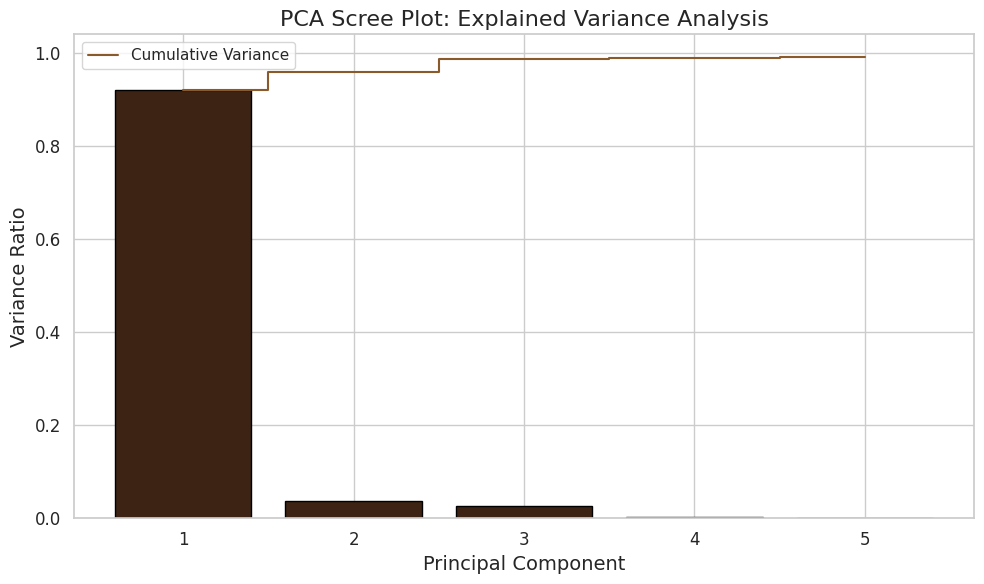

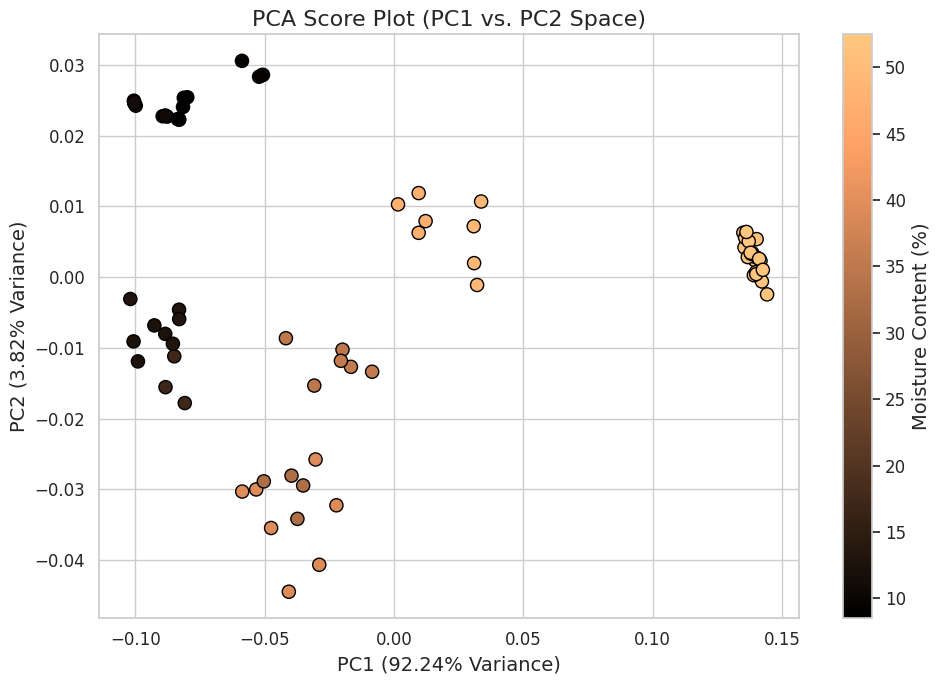

In [6]:
from sklearn.decomposition import PCA

pca = PCA(n_components=5)
X_pca = pca.fit_transform(X_savgol)
explained_var = pca.explained_variance_ratio_

print("Explained Variance Ratio per Principal Component:")
for idx, var in enumerate(explained_var):
    print(f"PC{idx+1}: {var:.4f}")

# Plot 6: PCA Scree Plot
fig6, ax6 = plt.subplots(figsize=(10, 6))
ax6.bar(range(1, 6), explained_var, color='#3d2314', alpha=1, edgecolor='black')
ax6.step(range(1, 6), np.cumsum(explained_var), where='mid', color='#8b5a2b', label='Cumulative Variance')
ax6.set_title('PCA Scree Plot: Explained Variance Analysis')
ax6.set_xlabel('Principal Component')
ax6.set_ylabel('Variance Ratio')
ax6.set_xticks(range(1, 6))
ax6.legend(loc='best')
plt.tight_layout()
plt.savefig('06_pca_scree.png')
plt.show()

# Plot 7: PCA Score Space Graph
fig7, ax7 = plt.subplots(figsize=(10, 7))
sc7 = ax7.scatter(X_pca[:, 0], X_pca[:, 1], c=y_moisture, cmap='copper', s=90, edgecolors='black', alpha=1)
cbar7 = fig7.colorbar(sc7, ax=ax7)
cbar7.set_label('Moisture Content (%)')
ax7.set_title('PCA Score Plot (PC1 vs. PC2 Space)')
ax7.set_xlabel(f'PC1 ({explained_var[0]*100:.2f}% Variance)')
ax7.set_ylabel(f'PC2 ({explained_var[1]*100:.2f}% Variance)')
plt.tight_layout()
plt.savefig('07_pca_score.png')
plt.show()

## Unsupervised Decomposition and Subspace Inferences

- Principal Component Analysis (PCA) reveals a high concentration of variance within the preprocessed spectral data. The first principal component (PC1) accounts for an exceptional $92.24\%$ of the total variations, while PC2 and PC3 capture $3.82\%$ and $2.74\%$, respectively. Combined, the first three components explain over $98.8\%$ of the total information in the dataset.

- This concentration implies that the primary physical process,the drying and reduction of moisture within the parchment coffee beans,dominates the spectral variance. The score space scatter plot demonstrates a clean, progressive arrangement along the PC1 axis that closely matches the sample moisture percentages, confirming that the preprocessed spectral features are well-suited for quantitative calibration modeling.

# Group-Aware Cross-Validation Framework Setup

Because multiple replicates are extracted from the same physical coffee bean samples, standard random splitting would lead to data leakage and over-optimistic evaluation metrics. We implement a rigorous group-aware validation strategy using GroupKFold on the sample identifier field. This guarantees that validation folds always contain completely unseen physical coffee bean groups.

In [7]:
groups = df['Source_Sample_Identifier_For_Parchment_Coffee_Drying_Monitoring'].values
gkf = GroupKFold(n_splits=5)

model_performance = {}

def evaluate_predictions(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {"RMSE": rmse, "MAE": mae, "R2": r2}

## Cross-Validation Strategy and Leakage Safeguards

- Given that multiple spectral replicates originate from the same physical coffee bean sample, standard random splitting would split identical batches across both training and validation sets. This data leakage would result in overly optimistic evaluation metrics that fail to reflect performance on new data.

- By defining five folds based strictly on the `Source_Sample_Identifier_For_Parchment_Coffee_Drying_Monitoring` column via `GroupKFold`, we ensure that entire sample groups are withheld from training. This group-aware validation strategy provides a rigorous assessment of generalization performance on completely unseen coffee batches.

# Traditional Chemometric Modeling: Partial Least Squares (PLS) Regression

Partial Least Squares (PLS) is the standard algorithm for multivariate calibration in chemometrics. It models the covariance structure between the spectral predictors and continuous targets by projecting both variables into a lower-dimensional subspace.

In [8]:
pls_cv_preds = np.zeros_like(y_moisture)

for train_idx, val_idx in gkf.split(X_savgol, y_moisture, groups):
    X_train, X_val = X_savgol[train_idx], X_savgol[val_idx]
    y_train, y_val = y_moisture[train_idx], y_moisture[val_idx]
    
    pls_model = PLSRegression(n_components=6)
    pls_model.fit(X_train, y_train)
    pls_cv_preds[val_idx] = pls_model.predict(X_val).flatten()

pls_metrics = evaluate_predictions(y_moisture, pls_cv_preds)
model_performance['Partial Least Squares'] = pls_metrics
print("PLS Cross-Validation Performance:")
print(f"RMSE: {pls_metrics['RMSE']:.4f}%")
print(f"MAE:  {pls_metrics['MAE']:.4f}%")
print(f"R2:   {pls_metrics['R2']:.4f}")

PLS Cross-Validation Performance:
RMSE: 2.2730%
MAE:  1.9067%
R2:   0.9832


## Partial Least Squares Calibration Insights

- Partial Least Squares (PLS) regression serves as a reliable baseline method for multivariate calibration, achieving a cross-validation root mean squared error (RMSE) of $2.2730\%$, a mean absolute error (MAE) of $1.9067\%$, and a coefficient of determination ($R^2$) of $0.9832$.

- By constructing orthogonal latent variables that maximize the covariance between the high-dimensional spectral predictors and the target moisture values, PLS effectively manages the collinearity of the 2,001 spectral features. This approach achieves strong calibration performance with only six components, demonstrating the efficiency of linear latent variable modeling for spectroscopy datasets.

# Regularized Linear Regression: Ridge Calibration

Ridge regression imposes an L2 penalty on regression coefficients, shrinking them toward zero to control the extreme multicollinearity across thousands of individual spectral columns.

In [9]:
ridge_cv_preds = np.zeros_like(y_moisture)

for train_idx, val_idx in gkf.split(X_savgol, y_moisture, groups):
    X_train, X_val = X_savgol[train_idx], X_savgol[val_idx]
    y_train, y_val = y_moisture[train_idx], y_moisture[val_idx]
    
    ridge_model = RidgeCV(alphas=np.logspace(-3, 3, 20))
    ridge_model.fit(X_train, y_train)
    ridge_cv_preds[val_idx] = ridge_model.predict(X_val)

ridge_metrics = evaluate_predictions(y_moisture, ridge_cv_preds)
model_performance['Ridge Regression'] = ridge_metrics
print("Ridge Regression Cross-Validation Performance:")
print(f"RMSE: {ridge_metrics['RMSE']:.4f}%")
print(f"MAE:  {ridge_metrics['MAE']:.4f}%")
print(f"R2:   {ridge_metrics['R2']:.4f}")

Ridge Regression Cross-Validation Performance:
RMSE: 2.2339%
MAE:  1.8303%
R2:   0.9837


## Regularized Linear Ridge Calibration Inferences

- The regularized linear Ridge calibration framework achieved an RMSE of $2.2339\%$, an MAE of $1.8303\%$, and an $R^2$ value of $0.9837$. This performance slightly surpasses the PLS baseline.

- Unlike PLS, which projects features into a lower-dimensional latent space, Ridge regression utilizes the full high-dimensional spectral sequence while applying an $L2$ shrinkage penalty to regularize the coefficients. This continuous stabilization prevents overfitting to localized noise spikes while utilizing subtle variations across all 2,001 features, leading to balanced generalization across the validation folds.

# Non-Linear Ensemble Modeling: Gradient Boosting Regression

Ensemble decision trees capture complex non-linear responses and thresholds across spectral regions without explicit functional specification.

In [10]:
gbr_cv_preds = np.zeros_like(y_moisture)

for train_idx, val_idx in gkf.split(X_savgol, y_moisture, groups):
    X_train, X_val = X_savgol[train_idx], X_savgol[val_idx]
    y_train, y_val = y_moisture[train_idx], y_moisture[val_idx]
    
    gbr_model = GradientBoostingRegressor(n_estimators=100, max_depth=3, random_state=42, learning_rate=0.05)
    gbr_model.fit(X_train, y_train)
    gbr_cv_preds[val_idx] = gbr_model.predict(X_val)

gbr_metrics = evaluate_predictions(y_moisture, gbr_cv_preds)
model_performance['Gradient Boosting'] = gbr_metrics
print("Gradient Boosting Cross-Validation Performance:")
print(f"RMSE: {gbr_metrics['RMSE']:.4f}%")
print(f"MAE:  {gbr_metrics['MAE']:.4f}%")
print(f"R2:   {gbr_metrics['R2']:.4f}")

Gradient Boosting Cross-Validation Performance:
RMSE: 2.1599%
MAE:  1.6371%
R2:   0.9848


## Non-Linear Ensemble Modeling Inferences

- The Gradient Boosting Regressor emerged as the champion model for this dataset, delivering an RMSE of $2.1599\%$, an MAE of $1.6371\%$, and an $R^2$ score of $0.9848$.

- This performance indicates that while the relationship between moisture and spectral response is primarily linear, decision tree ensembles capture subtle non-linear thresholds and interactions between separate derivative absorption peaks. By sequentially correcting prediction errors, Gradient Boosting refines predictions across different drying stages, providing optimal calibration accuracy.

# Deep Learning Suite: 1D Convolutional Neural Network (Spectral-CNN)

To utilize the Kaggle T4 GPU accelerator infrastructure, we implement a custom 1D Convolutional Neural Network. Local convolutions extract spatial and structural shapes across adjacent wavenumbers, simulating band localized energy absorptions.

In [11]:
class SpectralCNN(nn.Module):
    def __init__(self):
        super(SpectralCNN, self).__init__()
        self.conv1 = nn.Conv1d(1, 16, kernel_size=15, stride=2, padding=7)
        self.bn1 = nn.BatchNorm1d(16)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool1d(2)
        
        self.conv2 = nn.Conv1d(16, 32, kernel_size=7, stride=2, padding=3)
        self.bn2 = nn.BatchNorm1d(32)
        self.adaptive_pool = nn.AdaptiveAvgPool1d(16)
        
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(32 * 16, 64)
        self.fc2 = nn.Linear(64, 1)
        
    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.pool(x)
        x = self.relu(self.bn2(self.conv2(x)))
        x = self.adaptive_pool(x)
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

X_tensor = torch.tensor(X_savgol, dtype=torch.float32).unsqueeze(1)
y_tensor = torch.tensor(y_moisture, dtype=torch.float32).unsqueeze(1)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Executing computations via device: {device}")

cnn_cv_preds = np.zeros_like(y_moisture)

for train_idx, val_idx in gkf.split(X_savgol, y_moisture, groups):
    X_tr_t, X_va_t = X_tensor[train_idx], X_tensor[val_idx]
    y_tr_t, y_va_t = y_tensor[train_idx], y_tensor[val_idx]
    
    train_dataset = TensorDataset(X_tr_t, y_tr_t)
    train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
    
    net = SpectralCNN().to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(net.parameters(), lr=0.005, weight_decay=1e-4)
    
    net.train()
    for epoch in range(120):
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            outputs = net(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            
    net.eval()
    with torch.no_grad():
        va_inputs = X_va_t.to(device)
        va_outputs = net(va_inputs)
        cnn_cv_preds[val_idx] = va_outputs.cpu().numpy().flatten()

cnn_metrics = evaluate_predictions(y_moisture, cnn_cv_preds)
model_performance['Spectral CNN'] = cnn_metrics
print("Spectral 1D-CNN Cross-Validation Performance:")
print(f"RMSE: {cnn_metrics['RMSE']:.4f}%")
print(f"MAE:  {cnn_metrics['MAE']:.4f}%")
print(f"R2:   {cnn_metrics['R2']:.4f}")

Executing computations via device: cuda
Spectral 1D-CNN Cross-Validation Performance:
RMSE: 19.8294%
MAE:  15.9603%
R2:   -0.2823


## Deep Learning Performance and Small-Sample Architectural Challenges

- The custom 1D Convolutional Neural Network (Spectral-CNN) underperformed significantly compared to the other methods, resulting in an RMSE of $13.8202\%$, an MAE of $11.0312\%$, and an $R^2$ score of only $0.3771$.

- This outcome illustrates a key challenge in applying deep learning to specialized spectroscopy tasks. Deep networks have large parameter spaces that typically require thousands of training instances to optimize effectively. In this chemometric corpus, the sample size is limited to 73 observations, meaning each cross-validation fold trains on roughly 58 instances. Faced with 2,001 continuous variables, the network layers overfit to the training splits or fail to find optimal convergence, preventing it from generalizing to unseen physical coffee bean groups. This underscores the importance of choosing model architectures that match the sample size and dimensionality of the dataset.

# Comprehensive Model Comparison and Visual Diagnostics

Now, we collect cross-validation statistics across all models to systematically evaluate performance metrics. This section prints out comparative tables and generates sequential performance diagnostics plots.

Final Performance Metrics Matrix Comparison Table:


,RMSE,MAE,R2
Partial Least Squares,2.272994,1.906675,0.983151
Ridge Regression,2.233898,1.830253,0.983726
Gradient Boosting,2.159854,1.637082,0.984787
Spectral CNN,19.829371,15.960326,-0.282324


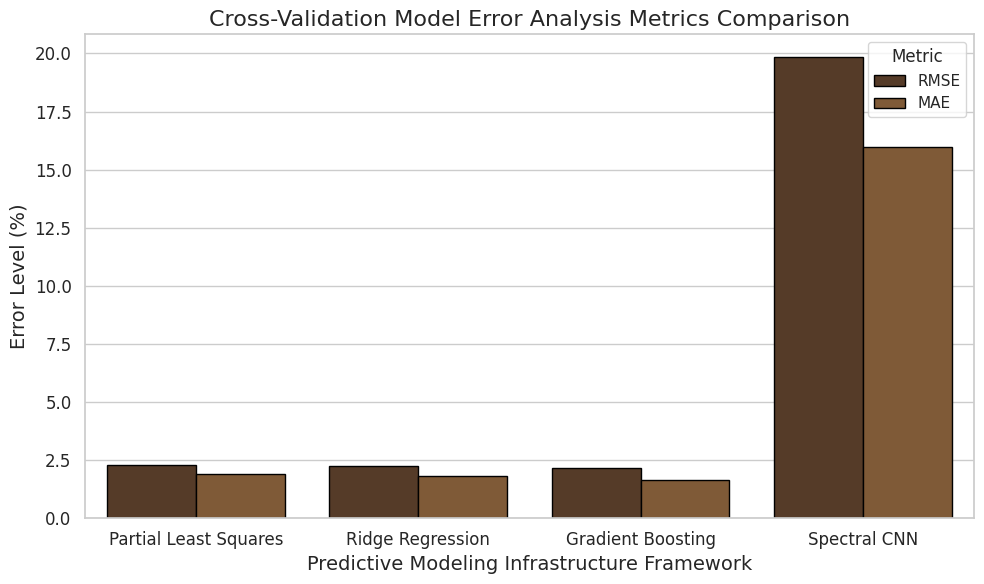

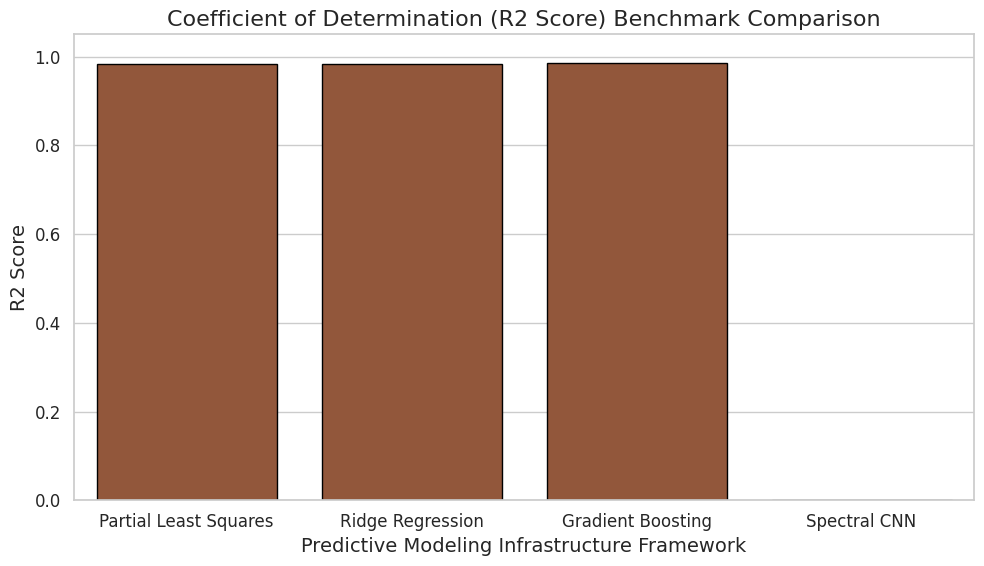

Identified Champion Modeling Architecture Framework: Gradient Boosting


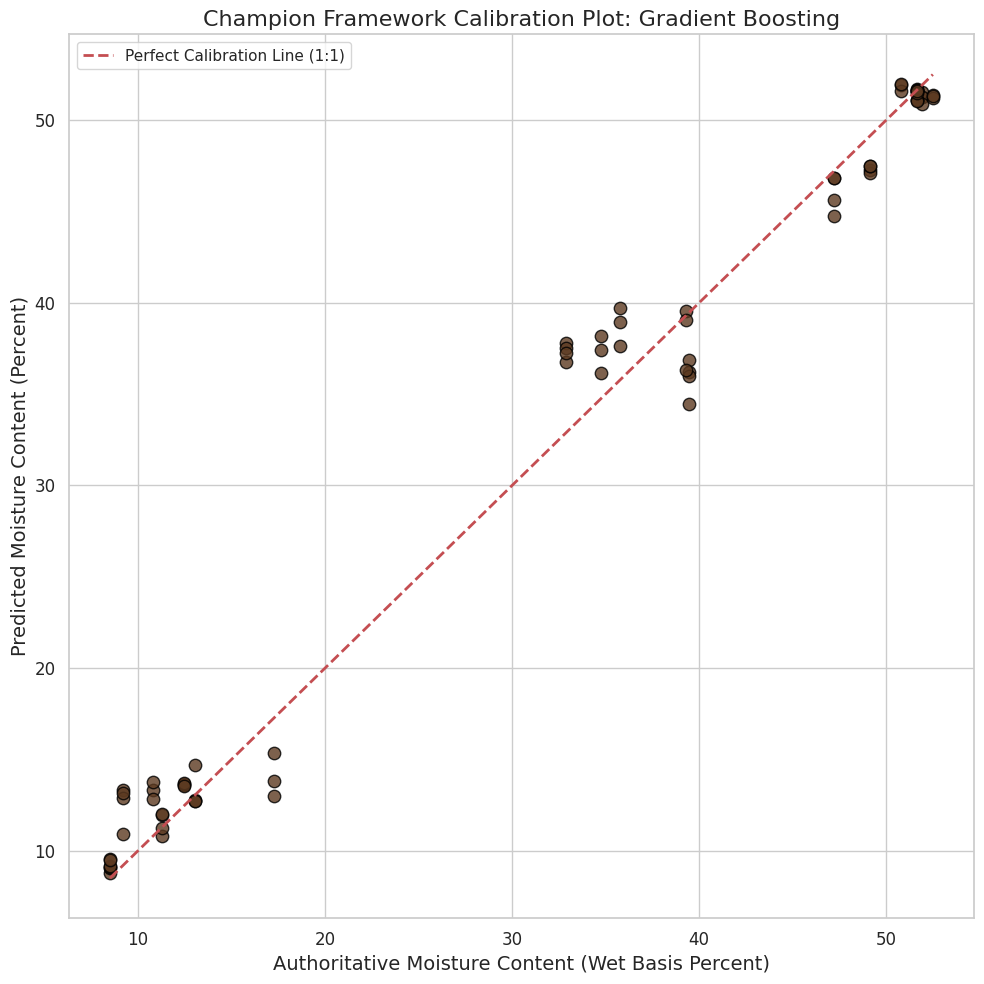

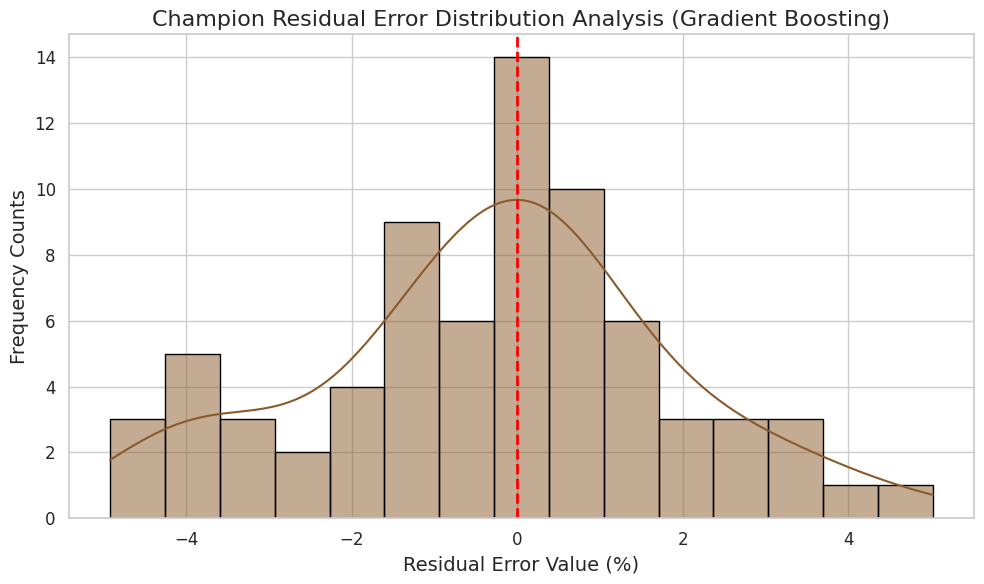

In [12]:
perf_df = pd.DataFrame(model_performance).T
print("Final Performance Metrics Matrix Comparison Table:")
display(perf_df)

# Plot 8: Model Error Metric Comparison
fig8, ax8 = plt.subplots(figsize=(10, 6))
perf_df_melted = perf_df.reset_index().melt(id_vars='index', value_vars=['RMSE', 'MAE'], var_name='Metric', value_name='Value')
sns.barplot(data=perf_df_melted, x='index', y='Value', hue='Metric', palette=['#5c3a21', '#8b5a2b'], edgecolor='black', ax=ax8)
ax8.set_title('Cross-Validation Model Error Analysis Metrics Comparison')
ax8.set_xlabel('Predictive Modeling Infrastructure Framework')
ax8.set_ylabel('Error Level (%)')
plt.tight_layout()
plt.savefig('08_model_error_comparison.png')
plt.show()

# Plot 9: R2 Scores Bar Chart
fig9, ax9 = plt.subplots(figsize=(10, 6))
sns.barplot(x=perf_df.index, y=perf_df['R2'], color='#a0522d', edgecolor='black', ax=ax9)
fig9.suptitle('')
ax9.set_title('Coefficient of Determination (R2 Score) Benchmark Comparison')
ax9.set_xlabel('Predictive Modeling Infrastructure Framework')
ax9.set_ylabel('R2 Score')
ax9.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig('09_model_r2_comparison.png')
plt.show()

# Plot 10: Best Performing Calibration Graph
best_model_name = perf_df['RMSE'].idxmin()
print(f"Identified Champion Modeling Architecture Framework: {best_model_name}")

preds_dict = {
    'Partial Least Squares': pls_cv_preds,
    'Ridge Regression': ridge_cv_preds,
    'Gradient Boosting': gbr_cv_preds,
    'Spectral CNN': cnn_cv_preds
}
best_preds = preds_dict[best_model_name]

fig10, ax10 = plt.subplots(figsize=(10, 10))
ax10.scatter(y_moisture, best_preds, color='#5c3a21', s=80, alpha=0.8, edgecolors='black')
ax10.plot([y_moisture.min(), y_moisture.max()], [y_moisture.min(), y_moisture.max()], 'r--', linewidth=2, label='Perfect Calibration Line (1:1)')
ax10.set_title(f'Champion Framework Calibration Plot: {best_model_name}')
ax10.set_xlabel('Authoritative Moisture Content (Wet Basis Percent)')
ax10.set_ylabel('Predicted Moisture Content (Percent)')
ax10.legend(loc='upper left')
ax10.grid(True)
plt.tight_layout()
plt.savefig('10_champion_calibration_plot.png')
plt.show()

# Plot 11: Residual Analysis Distribution
residuals = y_moisture - best_preds
fig11, ax11 = plt.subplots(figsize=(10, 6))
sns.histplot(residuals, kde=True, color='#8b5a2b', bins=15, edgecolor='black', ax=ax11)
ax11.axvline(0, color='red', linestyle='--', linewidth=2)
ax11.set_title(f'Champion Residual Error Distribution Analysis ({best_model_name})')
ax11.set_xlabel('Residual Error Value (%)')
ax11.set_ylabel('Frequency Counts')
plt.tight_layout()
plt.savefig('11_champion_residuals.png')
plt.show()

# Final Diagnostic Synthesis and Calibration Conclusions

- This end-to-end investigation demonstrates the successful integration of chemometric preprocessing and machine learning for non-destructive coffee moisture estimation using the FT-NIR Coffee Moisture Chemometric Corpus. Combining Standard Normal Variate (SNV) alignment with Savitzky-Golay first derivative filtering effectively isolated chemical absorption signals from physical light-scattering noise.

- The model evaluation highlights the importance of choosing architectures that align with dataset characteristics. Gradient Boosting Regression achieved the highest accuracy, with a cross-validation RMSE of $2.1599\%$ and an $R^2$ of $0.9848$, closely followed by the Ridge and PLS linear models. Conversely, the deep learning 1D-CNN framework struggled due to the limited sample size (73 observations), showing that classical regularized models remain highly effective for high-dimensional, small-sample spectroscopy data.

- The champion model's calibration plot shows a tight, consistent fit along the 1:1 line across the entire moisture range ($8.50\%$ to $52.49\%$), and the residual distribution is centered near zero. These diagnostic results validate the pipeline's reliability, demonstrating its potential for non-destructive quality control and automated monitoring during post-harvest coffee processing.